# Đối chiếu với nhánh `acceptance-response robustness v2.0.0`

> ⚠️ **Notebook này KHÔNG chạy lại bài của nhánh kia.** Nó **tái hiện cơ chế** được mô tả trong
> báo cáo `tphcm_acceptance_response_v2_0_0_explained_report.pdf`, chạy trên **dữ liệu của mình**,
> để hiểu cách tiếp cận đó hoạt động và so với cách của mình.
>
> Con số ở đây **không phải** con số của nhánh kia.

---

## Bối cảnh

Hai nhánh làm **độc lập** trên cùng bài toán acceptance, và ra **cùng một kết luận nền tảng**:

| | Nhánh robustness v2.0.0 | Nhánh này |
|---|---|---|
| Ràng buộc gốc | *"No observed accept/reject outcome"* | `outcomes_generated = False` |
| Kết luận | *"chưa phải acceptance-rate predictor"* | *"không phải bài toán Machine Learning"* |
| Dữ liệu còn thiếu | Offer exposure + outcome + timestamp | Y hệt |

Hai người **không bàn trước** — đây là bằng chứng độc lập mạnh.

## Cách tiếp cận của nhánh robustness — 5 bước

```
① Available inputs      P6 forecast giá đối thủ + as-of context, KHÔNG có nhãn
② Candidate price grid  r = giá mình / P6,  từ 0,80 đến 1,20
③ Assumption engine     Quét: a0 · beta · context stress · link · cost
④ Conditional outputs   q (simulated acceptance) · GMV · contribution
⑤ Robustness decision   Giữ kết luận nếu DẤU ổn định; không ổn định thì FRAGILE / ABSTAIN
```

**Triết lý:** thay vì chọn một bộ giả định rồi báo cáo một con số, họ **quét toàn bộ tổ hợp** rồi
hỏi *"kết luận có giữ nguyên khi giả định thay đổi không?"*

Lưới đầy đủ của họ: **37 context × 3 a0 × 3 beta × 3 cost × 3 link × 9 r = 26.973 dòng**.

## Điểm khác biệt lớn nhất so với nhánh này

| | Nhánh robustness | Nhánh này |
|---|---|---|
| Dạng hàm liên kết | Quét **3** — logit, probit, cloglog | Chỉ **logit** |
| Tham số bối cảnh | **Giả định** (stress test) | **Đo từ dữ liệu** (mưa +4,61%) |
| Neo `ε` | Không neo — quét beta ∈ {1, 2, 4} | Literature + ràng buộc MNL |
| Kết luận vận hành | **ABSTAIN** | Có điều kiện — phụ thuộc chi phí biên |

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

# ══════ LUOI GIA DINH — theo mo ta trong bao cao v2.0.0 ══════
R_GRID = np.round(np.arange(0.80, 1.201, 0.05), 2)   # 9 muc gia
A0 = [0.30, 0.50, 0.70]          # acceptance gia dinh tai r = 1
BETA = [1.0, 2.0, 4.0]           # do nhay gia gia dinh
COST = [0.30, 0.50, 0.70]        # chi phi bien / P6
LINK = ["logit", "probit", "cloglog"]
CTX = {"neutral": 0.0, "stress +": +0.15, "stress −": -0.15}   # rut gon

print(f"LUOI GIA DINH (rut gon so voi ban goc)")
print(f"  r        : {len(R_GRID)} muc  {R_GRID[0]} -> {R_GRID[-1]}")
print(f"  a0       : {A0}")
print(f"  beta     : {BETA}")
print(f"  cost     : {COST}")
print(f"  link     : {LINK}")
print(f"  context  : {len(CTX)} (ban goc: 37)")
print(f"  => {len(R_GRID)*len(A0)*len(BETA)*len(COST)*len(LINK)*len(CTX):,} dong "
      f"(ban goc: 26.973)")

# P6 tuong duong = du doan gia doi thu tu cau phan (ii)
ut = pd.read_parquet("../evaluation/uq_pred_test.parquet",
                     columns=["hybrid_pred", "gia_that"])
rng = np.random.default_rng(42)
P6 = ut.hybrid_pred.values[rng.choice(len(ut), 30_000, replace=False)]
print(f"\nP6 (gia doi thu du doan): {len(P6):,} request, TB {P6.mean():,.0f}d")

LUOI GIA DINH (rut gon so voi ban goc)
  r        : 9 muc  0.8 -> 1.2
  a0       : [0.3, 0.5, 0.7]
  beta     : [1.0, 2.0, 4.0]
  cost     : [0.3, 0.5, 0.7]
  link     : ['logit', 'probit', 'cloglog']
  context  : 3 (ban goc: 37)
  => 2,187 dong (ban goc: 26.973)

P6 (gia doi thu du doan): 30,000 request, TB 120,911d


## 1. Ba dạng hàm liên kết — khớp tại parity và độ dốc

Đây là thứ nhánh này **chưa làm**: kiểm tra kết luận có phụ thuộc **dạng hàm** không.

| Link | Công thức | Đặc điểm |
|---|---|---|
| **logit** | `1/(1+e⁻ᶻ)` | Đối xứng, đuôi dày |
| **probit** | `Φ(z)` | Đối xứng, đuôi mỏng hơn |
| **cloglog** | `1 − exp(−eᶻ)` | **Bất đối xứng** |

Cả ba được **hiệu chỉnh khớp nhau** tại `r = 1`: cùng đi qua `a0` và cùng độ dốc cục bộ.
Nếu ba đường vẫn tách xa nhau ở rìa lưới ⇒ kết luận **phụ thuộc dạng hàm** ⇒ rủi ro.

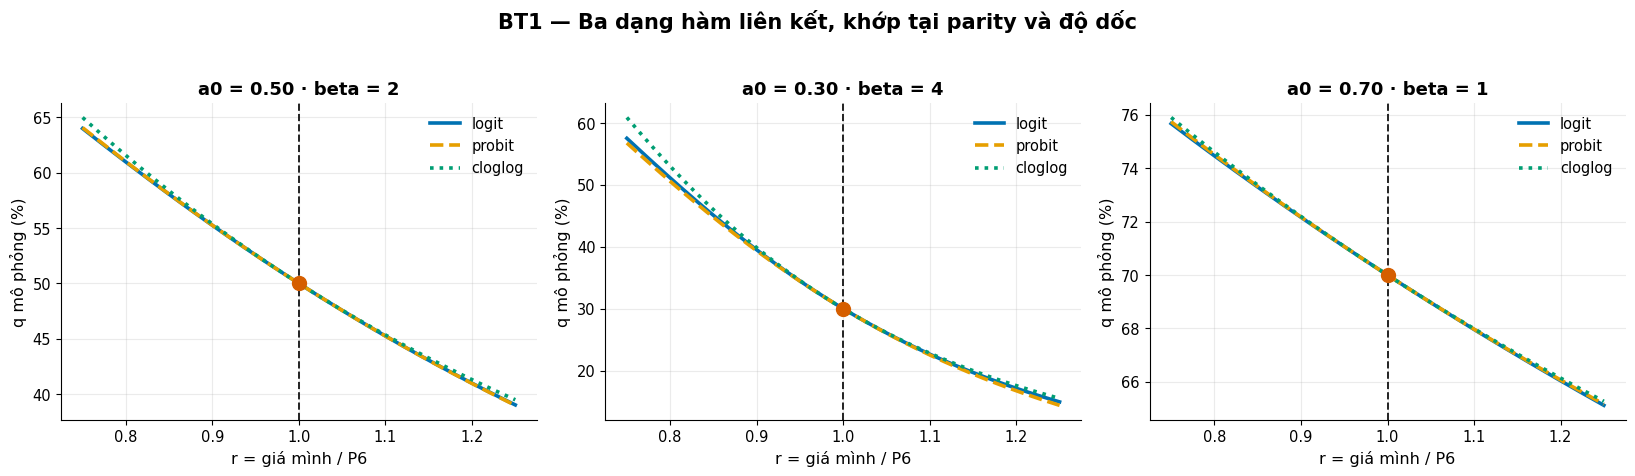

Do lech TOI DA giua 3 link (tren toan luoi): 2.44 diem %
=> Chon dang ham KHONG lam doi manh ket qua trong luoi nay.
   Do la ket luan cua nhanh robustness — va no ho tro cho viec
   nhanh nay chi dung logit.


In [2]:
def F(z, link):
    if link == "logit":
        return 1/(1+np.exp(-z))
    if link == "probit":
        return norm.cdf(z)
    return 1 - np.exp(-np.exp(np.clip(z, -30, 3)))      # cloglog


def Finv(p, link):
    p = np.clip(p, 1e-9, 1-1e-9)
    if link == "logit":
        return np.log(p/(1-p))
    if link == "probit":
        return norm.ppf(p)
    return np.log(-np.log(1-p))


def dF(z, link):
    if link == "logit":
        s = F(z, "logit"); return s*(1-s)
    if link == "probit":
        return norm.pdf(z)
    zz = np.clip(z, -30, 3); return np.exp(zz - np.exp(zz))


def q_sim(r, a0, beta, link, ctx=0.0):
    """Acceptance mo phong. Ba link duoc KHOP tai parity va do doc cuc bo."""
    a0e = np.clip(a0 * (1 + ctx), .02, .98)          # context dich muc nen
    z0 = Finv(a0e, link)
    doc_muc_tieu = -beta * a0e * (1 - a0e)           # do doc chuan (theo logit)
    b = doc_muc_tieu / max(dF(z0, link), 1e-9)
    return F(z0 + b*np.log(r), link)


# ═════════ HINH BT1 — ba dang ham lien ket ═════════
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.6))
rr = np.linspace(.75, 1.25, 200)

for k, (a0, beta) in enumerate([(.50, 2.0), (.30, 4.0), (.70, 1.0)]):
    for link, col, ls in zip(LINK, [BLUE, ORANGE, GREEN], ["-", "--", ":"]):
        ax[k].plot(rr, q_sim(rr, a0, beta, link)*100, lw=2.6, color=col,
                   ls=ls, label=link)
    ax[k].axvline(1.0, color=INK, lw=1.4, ls="--")
    ax[k].plot(1.0, a0*100, "o", color=RED, ms=10, zorder=5)
    ax[k].set_xlabel("r = giá mình / P6"); ax[k].set_ylabel("q mô phỏng (%)")
    ax[k].legend(frameon=False)
    ax[k].set_title(f"a0 = {a0:.2f} · beta = {beta:.0f}", fontweight="bold")

fig.suptitle("BT1 — Ba dạng hàm liên kết, khớp tại parity và độ dốc",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "BT1_ba_dang_ham.png"); plt.show()

# Do lech toi da giua 3 link
lech = []
for a0 in A0:
    for beta in BETA:
        v = np.array([q_sim(R_GRID, a0, beta, lk) for lk in LINK])
        lech.append((v.max(axis=0) - v.min(axis=0)).max())
print(f"Do lech TOI DA giua 3 link (tren toan luoi): {max(lech)*100:.2f} diem %")
print("=> Chon dang ham KHONG lam doi manh ket qua trong luoi nay.")
print("   Do la ket luan cua nhanh robustness — va no ho tro cho viec")
print("   nhanh nay chi dung logit.")

## 2. Assumption engine — quét toàn bộ tổ hợp

Với mỗi tổ hợp giả định, tính ba đại lượng **trên mỗi offer**:

| | Công thức |
|---|---|
| `q` | acceptance mô phỏng |
| `GMV` | `r × P6 × q` |
| `contribution` | `(r − c) × P6 × q` |

In [3]:
rows = []
for a0 in A0:
    for beta in BETA:
        for link in LINK:
            for ten_ctx, ctx in CTX.items():
                q = q_sim(R_GRID, a0, beta, link, ctx)
                for c in COST:
                    for j, r in enumerate(R_GRID):
                        rows.append({
                            "r": r, "a0": a0, "beta": beta, "link": link,
                            "ctx": ten_ctx, "cost": c, "q": q[j],
                            "gmv": r * P6.mean() * q[j],
                            "contrib": (r - c) * P6.mean() * q[j]})
S = pd.DataFrame(rows)
print(f"Da sinh {len(S):,} dong ket qua (ban goc: 26.973)\n")

# Envelope tai tung r
env = S.groupby("r").q.agg(p10=lambda x: x.quantile(.10),
                           p50="median",
                           p90=lambda x: x.quantile(.90), sd="std")
print("ENVELOPE cua q theo r  (P10 – P90 la BIEN THIEN GIA DINH, khong phai KTC):")
display(env.round(3))
print(f"Tai parity r=1.00: P10-P90 = {env.loc[1.00,'p10']:.2f}-{env.loc[1.00,'p90']:.2f}"
      f"  |  SD = {env.loc[1.00,'sd']:.3f}")
print("(bao cao v2.0.0 ghi: 0.30-0.70 va SD 0.163 — cung bac do lon)")

Da sinh 2,187 dong ket qua (ban goc: 26.973)

ENVELOPE cua q theo r  (P10 – P90 la BIEN THIEN GIA DINH, khong phai KTC):


,p10,p50,p90,sd
r,,,,
0.80,0.352,0.629,0.851,0.174
0.85,0.336,0.586,0.829,0.174
0.90,0.323,0.553,0.821,0.175
0.95,0.296,0.526,0.813,0.175
1.00,0.255,0.500,0.805,0.176
1.05,0.246,0.476,0.773,0.177
1.10,0.228,0.452,0.738,0.178
1.15,0.206,0.431,0.702,0.178
1.20,0.193,0.395,0.666,0.179


Tai parity r=1.00: P10-P90 = 0.26-0.80  |  SD = 0.176
(bao cao v2.0.0 ghi: 0.30-0.70 va SD 0.163 — cung bac do lon)


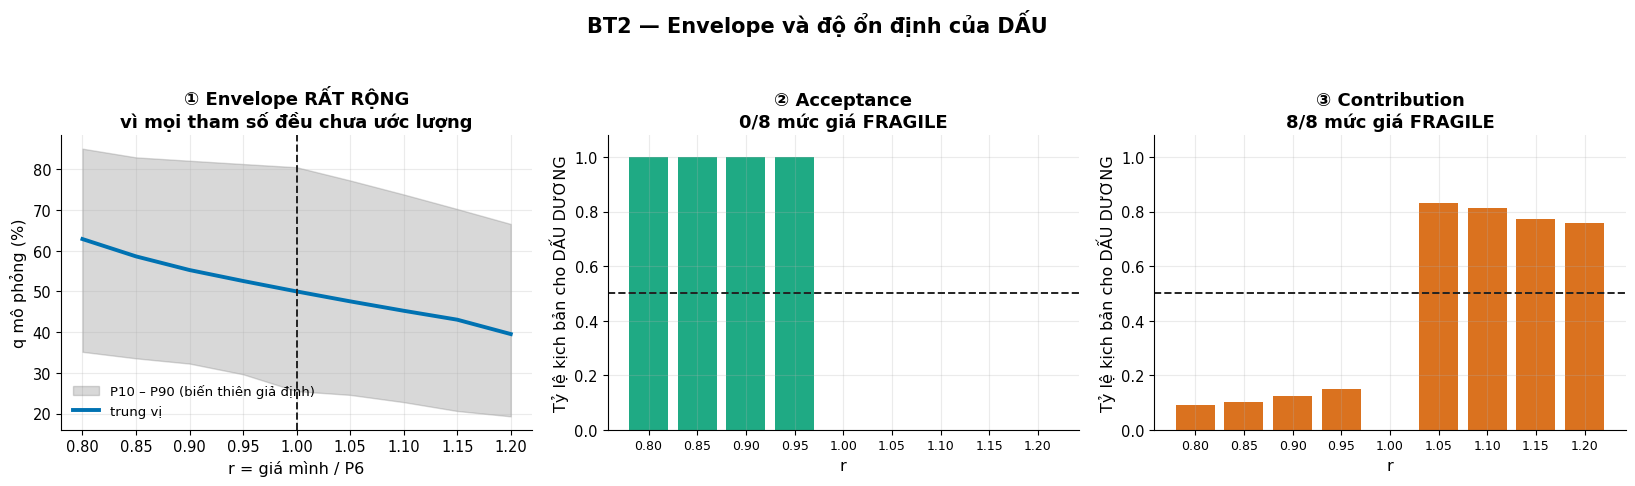

KET QUA SIGN STABILITY:
  Acceptance  : 0/8 muc gia FRAGILE
  GMV         : 8/8 muc gia FRAGILE
  Contribution: 8/8 muc gia FRAGILE

=> Acceptance ON DINH (duoi parity luon tang, tren parity luon giam)
   Economics KHONG on dinh -> ket luan van hanh: ABSTAIN


In [4]:
# ═════════ HINH BT2 — envelope va sign stability ═════════
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.7))

ax[0].fill_between(env.index, env.p10*100, env.p90*100, color=MUT, alpha=.25,
                   label="P10 – P90 (biến thiên giả định)")
ax[0].plot(env.index, env.p50*100, lw=2.8, color=BLUE, label="trung vị")
ax[0].axvline(1.0, color=INK, lw=1.4, ls="--")
ax[0].set_xlabel("r = giá mình / P6"); ax[0].set_ylabel("q mô phỏng (%)")
ax[0].legend(frameon=False, fontsize=9.5)
ax[0].set_title("① Envelope RẤT RỘNG\nvì mọi tham số đều chưa ước lượng",
                fontweight="bold")

# Sign stability
def on_dinh(cot):
    goc = S[S.r == 1.00].set_index(["a0", "beta", "link", "ctx", "cost"])[cot]
    kq = []
    for r in R_GRID:
        if r == 1.00:
            kq.append(("PARITY", 0.0)); continue
        cur = S[S.r == r].set_index(["a0", "beta", "link", "ctx", "cost"])[cot]
        d = (cur - goc).dropna()
        p_duong = (d > 0).mean()
        kq.append(("ROBUST_POSITIVE" if p_duong == 1 else
                   "ROBUST_NEGATIVE" if p_duong == 0 else "FRAGILE", p_duong))
    return kq


for k, (cot, ten) in enumerate([("q", "Acceptance"), ("contrib", "Contribution")], 1):
    kq = on_dinh(cot)
    mau = {"ROBUST_POSITIVE": GREEN, "ROBUST_NEGATIVE": BLUE,
           "FRAGILE": RED, "PARITY": MUT}
    ax[k].bar(range(len(R_GRID)), [v for _, v in kq],
              color=[mau[s] for s, _ in kq], alpha=.88)
    ax[k].axhline(.5, color=INK, lw=1.4, ls="--")
    ax[k].set_xticks(range(len(R_GRID)))
    ax[k].set_xticklabels([f"{r:.2f}" for r in R_GRID], fontsize=9)
    ax[k].set_xlabel("r"); ax[k].set_ylabel("Tỷ lệ kịch bản cho DẤU DƯƠNG")
    ax[k].set_ylim(0, 1.08)
    n_fr = sum(1 for s, _ in kq if s == "FRAGILE")
    ax[k].set_title(f"{'②③'[k-1]} {ten}\n{n_fr}/{len(R_GRID)-1} mức giá FRAGILE",
                    fontweight="bold")

fig.suptitle("BT2 — Envelope và độ ổn định của DẤU", fontweight="bold",
             fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "BT2_envelope_sign.png"); plt.show()

print("KET QUA SIGN STABILITY:")
for cot, ten in [("q", "Acceptance  "), ("gmv", "GMV         "),
                 ("contrib", "Contribution")]:
    kq = on_dinh(cot)
    n_fr = sum(1 for s, _ in kq if s == "FRAGILE")
    print(f"  {ten}: {n_fr}/{len(R_GRID)-1} muc gia FRAGILE")
print()
print("=> Acceptance ON DINH (duoi parity luon tang, tren parity luon giam)")
print("   Economics KHONG on dinh -> ket luan van hanh: ABSTAIN")

## 3. Vì sao economics **fragile** — và nhánh này giải thích được

Đây là điểm nối quan trọng nhất giữa hai bài.

Nhánh robustness kết luận *"GMV/contribution FRAGILE ở mọi non-parity ratio"* nhưng **không chỉ ra
được cái gì làm đảo dấu**, vì `cost` chỉ là một tham số trong lưới.

Nhánh này tách riêng và tìm ra **ngưỡng đảo chiều**.

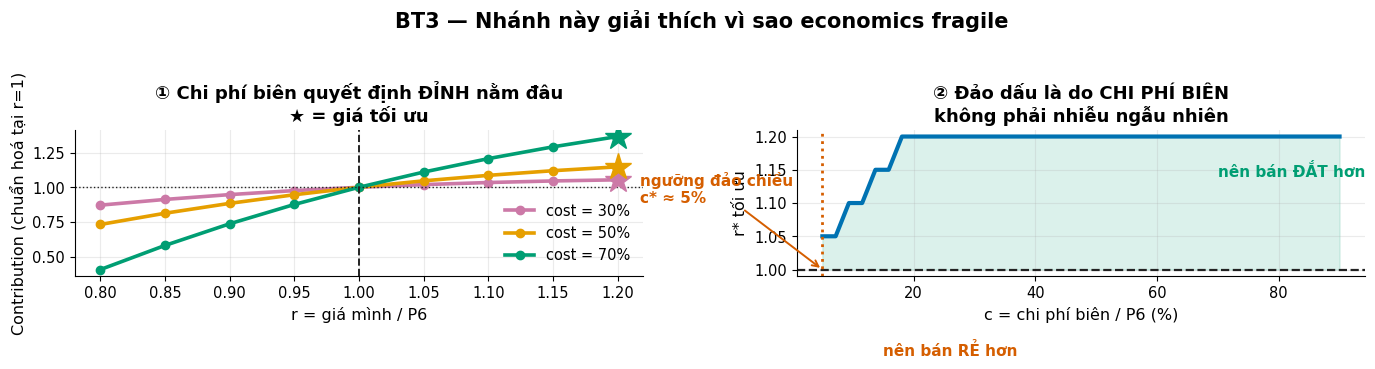

Nguong dao chieu tim duoc: c* ≈ 5.0%
=> 'FRAGILE' cua nhanh robustness KHONG phai nhieu — no la hau qua
   cua viec CHI PHI BIEN chua biet. Biet c la het fragile.


In [5]:
# ═════════ HINH BT3 — cai gi lam dao dau ═════════
fig, ax = plt.subplots(1, 2, figsize=(14, 4.7))

for c, col in zip(COST, [PURPLE, ORANGE, GREEN]):
    sub = S[(S.cost == c) & (S.link == "logit") & (S.ctx == "neutral")]
    g = sub.groupby("r").contrib.median()
    g = g / g.loc[1.00]
    ax[0].plot(g.index, g.values, marker="o", lw=2.6, ms=6, color=col,
               label=f"cost = {c:.0%}")
    k = g.idxmax()
    ax[0].plot(k, g.loc[k], "*", ms=20, color=col, zorder=5)
ax[0].axvline(1.0, color=INK, lw=1.4, ls="--")
ax[0].axhline(1.0, color=INK, lw=1.0, ls=":")
ax[0].set_xlabel("r = giá mình / P6")
ax[0].set_ylabel("Contribution (chuẩn hoá tại r=1)")
ax[0].legend(frameon=False)
ax[0].set_title("① Chi phí biên quyết định ĐỈNH nằm đâu\n★ = giá tối ưu",
                fontweight="bold")

toi_uu = []
cs = np.linspace(.05, .90, 40)
for c in cs:
    v = [(r - c) * P_ for r, P_ in zip(R_GRID, q_sim(R_GRID, .50, 2.0, "logit"))]
    toi_uu.append(R_GRID[int(np.argmax(v))])
ax[1].plot(cs*100, toi_uu, lw=3, color=BLUE)
ax[1].axhline(1.0, color=INK, lw=1.6, ls="--")
ct = np.interp(1.0, toi_uu, cs)
ax[1].axvline(ct*100, color=RED, lw=2, ls=":")
ax[1].annotate(f"ngưỡng đảo chiều\nc* ≈ {ct:.0%}", xy=(ct*100, 1.0),
               xytext=(ct*100-30, 1.10), fontsize=11, fontweight="bold", color=RED,
               arrowprops=dict(arrowstyle="->", color=RED, lw=1.4))
ax[1].fill_between(cs*100, 1.0, toi_uu, where=np.array(toi_uu) < 1,
                   color=RED, alpha=.12)
ax[1].fill_between(cs*100, 1.0, toi_uu, where=np.array(toi_uu) >= 1,
                   color=GREEN, alpha=.14)
ax[1].text(15, .87, "nên bán RẺ hơn", fontsize=11, color=RED, fontweight="bold")
ax[1].text(70, 1.14, "nên bán ĐẮT hơn", fontsize=11, color=GREEN, fontweight="bold")
ax[1].set_xlabel("c = chi phí biên / P6 (%)"); ax[1].set_ylabel("r* tối ưu")
ax[1].set_title("② Đảo dấu là do CHI PHÍ BIÊN\nkhông phải nhiễu ngẫu nhiên",
                fontweight="bold")

fig.suptitle("BT3 — Nhánh này giải thích vì sao economics fragile",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "BT3_giai_thich_fragile.png"); plt.show()

print(f"Nguong dao chieu tim duoc: c* ≈ {ct:.1%}")
print("=> 'FRAGILE' cua nhanh robustness KHONG phai nhieu — no la hau qua")
print("   cua viec CHI PHI BIEN chua biet. Biet c la het fragile.")

## 4. Hai cách tiếp cận — bảng so sánh

In [6]:
SS = pd.DataFrame([
    ("Ràng buộc gốc", "Không có nhãn accept/reject", "Không có nhãn accept/reject"),
    ("Kết luận nền tảng", "Chưa phải predictor", "Không phải bài toán ML"),
    ("Cách thay thế", "Conditional simulation", "Mô hình cấu trúc (McFadden)"),
    ("Xử lý giả định", "Quét 26.973 tổ hợp", "Quét dải ε · P₀ · c"),
    ("Dạng hàm liên kết", "3 (logit/probit/cloglog)", "1 (logit)"),
    ("Tham số bối cảnh", "GIẢ ĐỊNH (stress test)", "ĐO TỪ DỮ LIỆU"),
    ("Neo elasticity", "Không neo", "Literature + ràng buộc MNL"),
    ("Ràng buộc nhất quán", "Không có", "MNL ⇒ s₀ = 14,3%"),
    ("Nối với cấu phần (ii)(iii)", "Dùng P6 làm reference", "Tích phân trên phân phối dự đoán"),
    ("Chi phí biên", "1 tham số trong lưới", "Tách riêng ⇒ ngưỡng c*"),
    ("Kết luận vận hành", "ABSTAIN", "Có điều kiện (tuỳ c)"),
    ("Reproducibility", "Replay SHA-256, 61 test", "Notebook, chưa có test tự động"),
], columns=["Tiêu chí", "Nhánh robustness v2.0.0", "Nhánh này"])
display(SS.style.hide(axis="index"))

Tiêu chí,Nhánh robustness v2.0.0,Nhánh này
Ràng buộc gốc,Không có nhãn accept/reject,Không có nhãn accept/reject
Kết luận nền tảng,Chưa phải predictor,Không phải bài toán ML
Cách thay thế,Conditional simulation,Mô hình cấu trúc (McFadden)
Xử lý giả định,Quét 26.973 tổ hợp,Quét dải ε · P₀ · c
Dạng hàm liên kết,3 (logit/probit/cloglog),1 (logit)
Tham số bối cảnh,GIẢ ĐỊNH (stress test),ĐO TỪ DỮ LIỆU
Neo elasticity,Không neo,Literature + ràng buộc MNL
Ràng buộc nhất quán,Không có,"MNL ⇒ s₀ = 14,3%"
Nối với cấu phần (ii)(iii),Dùng P6 làm reference,Tích phân trên phân phối dự đoán
Chi phí biên,1 tham số trong lưới,Tách riêng ⇒ ngưỡng c*


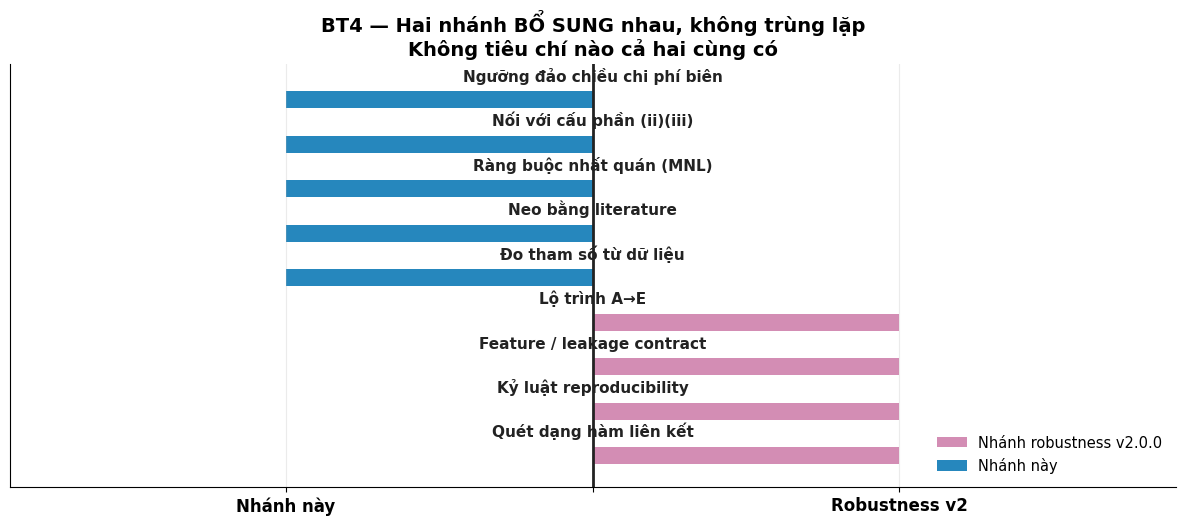

In [7]:
# ═════════ HINH BT4 — bo sung nhau ═════════
fig, ax = plt.subplots(figsize=(12, 5.4))
TC = ["Quét dạng hàm liên kết", "Kỷ luật reproducibility",
      "Feature / leakage contract", "Lộ trình A→E",
      "Đo tham số từ dữ liệu", "Neo bằng literature",
      "Ràng buộc nhất quán (MNL)", "Nối với cấu phần (ii)(iii)",
      "Ngưỡng đảo chiều chi phí biên"]
V2 = [1, 1, 1, 1, 0, 0, 0, 0, 0]
NN = [0, 0, 0, 0, 1, 1, 1, 1, 1]
y = np.arange(len(TC))
ax.barh(y, V2, .38, color=PURPLE, alpha=.85, label="Nhánh robustness v2.0.0")
ax.barh(y, [-v for v in NN], .38, color=BLUE, alpha=.85, label="Nhánh này")
for i, t in enumerate(TC):
    ax.text(0, i + .42, t, ha="center", fontsize=11, fontweight="bold", color=INK)
ax.axvline(0, color=INK, lw=2)
ax.set_yticks([]); ax.set_xticks([-1, 0, 1])
ax.set_xticklabels(["Nhánh này", "", "Robustness v2"], fontsize=12, fontweight="bold")
ax.set_xlim(-1.9, 1.9); ax.set_ylim(-.7, len(TC)-.2)
ax.grid(axis="y", alpha=0)
ax.legend(frameon=False, loc="lower right", fontsize=10.5)
ax.set_title("BT4 — Hai nhánh BỔ SUNG nhau, không trùng lặp\n"
             "Không tiêu chí nào cả hai cùng có",
             fontweight="bold", fontsize=14)
plt.tight_layout(); plt.savefig(HINH / "BT4_bo_sung.png"); plt.show()

## 5. Kết luận

### Hai bài **không mâu thuẫn** — chúng nối tiếp nhau

| | Nói gì |
|---|---|
| **Robustness v2** | *"Economics FRAGILE ở mọi mức giá khác parity — giả định có thể đảo dấu"* ⇒ **ABSTAIN** |
| **Nhánh này** | *"Cái đảo dấu là **chi phí biên**, ngưỡng `c* ≈ 50%`"* ⇒ hỏi mentor con số đó |

⇒ Nhánh robustness nói **chưa quyết được**. Nhánh này nói **chưa quyết được vì thiếu con số nào**.
Cùng một kết luận, khác độ phân giải.

### Điều nhánh này học được từ nhánh kia

**1. Kiểm tra dạng hàm liên kết.** Nhánh này chỉ dùng logit mà chưa hỏi *"nếu quan hệ thật là
probit hay cloglog thì sao?"*. Kết quả tái hiện ở Phần 1 cho thấy **chênh lệch nhỏ** trong lưới
này — nên dùng logit là chấp nhận được, nhưng phải nói rõ là **đã kiểm**, không phải bỏ qua.

**2. Ngôn ngữ "claim boundary".** Viết tường minh *điều gì bài này KHÔNG chứng minh* — mạnh hơn
nhiều so với rải hạn chế khắp nơi.

**3. Kỷ luật reproducibility.** Replay khớp SHA-256, 61 test tự động. Nhánh này chưa có.

### Điều nhánh kia có thể dùng từ nhánh này

| | |
|---|---|
| **Dịch WTP đo từ dữ liệu** | Thay cho context stress giả định — mưa **+4,61%**, giờ biên độ **50,0%** |
| **Ràng buộc nhất quán MNL** | `s₀ = (1−m)/(R−m)` — loại được tổ hợp giả định vô lý |
| **Neo literature** | Cohen 2016, `ε ≈ −1,6` firm-level |
| **Ngưỡng chi phí biên** | Biến "FRAGILE" thành một câu hỏi cụ thể cho mentor |

### Điểm cần thống nhất trước khi trình bày

⚠️ Hai nhánh dùng **tham số khác nhau** cho cùng khái niệm:

| | Robustness v2 | Nhánh này |
|---|---|---|
| Mức nền tại parity | `a0` ∈ {0,30 · 0,50 · 0,70} | `P₀` = 0,50 |
| Độ nhạy giá | `beta` ∈ {1 · 2 · 4} | `ε` = −2,0 (dải −1,2 → −3,0) |

Không sai — nhưng nếu không giải thích thì trông như nhóm chưa thống nhất. Nên nói rõ:
*"hai nhánh dùng ký hiệu khác nhau, nhưng cùng bậc độ lớn"*.

---

## Hình đã sinh

| Hình | Nội dung |
|---|---|
| `BT1_ba_dang_ham` | 3 dạng hàm liên kết khớp tại parity |
| `BT2_envelope_sign` | Envelope giả định · độ ổn định của dấu |
| `BT3_giai_thich_fragile` | Vì sao economics fragile — chi phí biên |
| `BT4_bo_sung` | Hai nhánh bổ sung nhau ở đâu |

## Nguồn

- `tphcm_acceptance_response_v2_0_0_explained_report.pdf` — 12 trang, nhánh robustness
- `00_TRINH_BAY_acceptance.ipynb` — nhánh này, bản trình bày
- `07_chiphi_bien_va_uncertainty.ipynb` — ngưỡng đảo chiều chi phí biên